In [2]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import pandas as pd
from astropy.table import Table, vstack

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
sys.path.append('/mnt/home/ktavangar/projects/MSSA_Snails/code/')
import importlib
import helper

In [3]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams.update({
    'axes.linewidth': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    "lines.color": "white",
    "patch.edgecolor": "white",
    "text.color": "black",
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white"})

## Look at Populations in Annuli at Different Times

In [4]:
importlib.reload(sys.modules['load_data_B2'])
from load_data_B2 import setup_B2, setup_B2_subset

data100 = setup_B2(100, actions_only=True, extras=True)
data150 = setup_B2(150, actions_only=True, extras=True)
data200 = setup_B2(200, actions_only=True, extras=True)
data250 = setup_B2(250, actions_only=True, extras=True)
data300 = setup_B2(300, actions_only=True, extras=True)
data350 = setup_B2(350, actions_only=True, extras=True)
data400 = setup_B2(400, actions_only=True, extras=True)
data450 = setup_B2(450, actions_only=True, extras=True)

Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...


In [ ]:
outer100 = data100[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer150 = data150[(data150.jphi > 2000) & (data150.jphi < 3000)]
outer200 = data200[(data200.jphi > 2000) & (data300.jphi < 3000)]
outer250 = data250[(data250.jphi > 2000) & (data250.jphi < 3000)]
outer300 = data300[(data300.jphi > 2000) & (data300.jphi < 3000)]
outer350 = data350[(data350.jphi > 2000) & (data350.jphi < 3000)]
outer400 = data400[(data400.jphi > 2000) & (data400.jphi < 3000)]
outer450 = data450[(data450.jphi > 2000) & (data450.jphi < 3000)]

In [47]:
outer_original150 = data150[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original200 = data200[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original250 = data250[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original300 = data300[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original350 = data350[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original400 = data400[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original450 = data450[(data100.jphi > 2000) & (data100.jphi < 3000)]

## Let's Make Some Histograms Before the Interaction

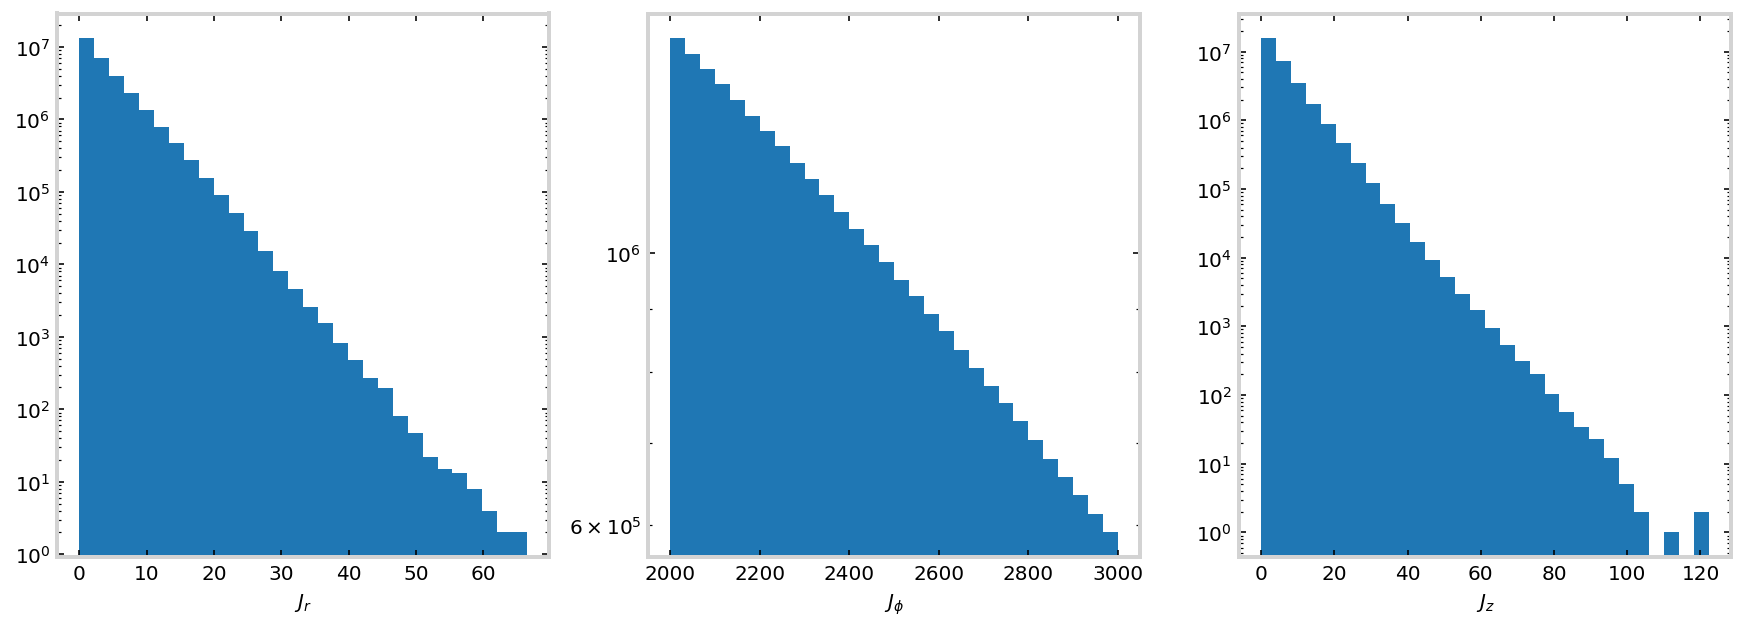

In [31]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer100.jr, bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer100.jphi, bins=30)
axs[1].set_xlabel(r'$J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer100.jz, bins=30)
axs[2].set_xlabel(r'$J_z$')
axs[2].set_yscale('log')
plt.show()

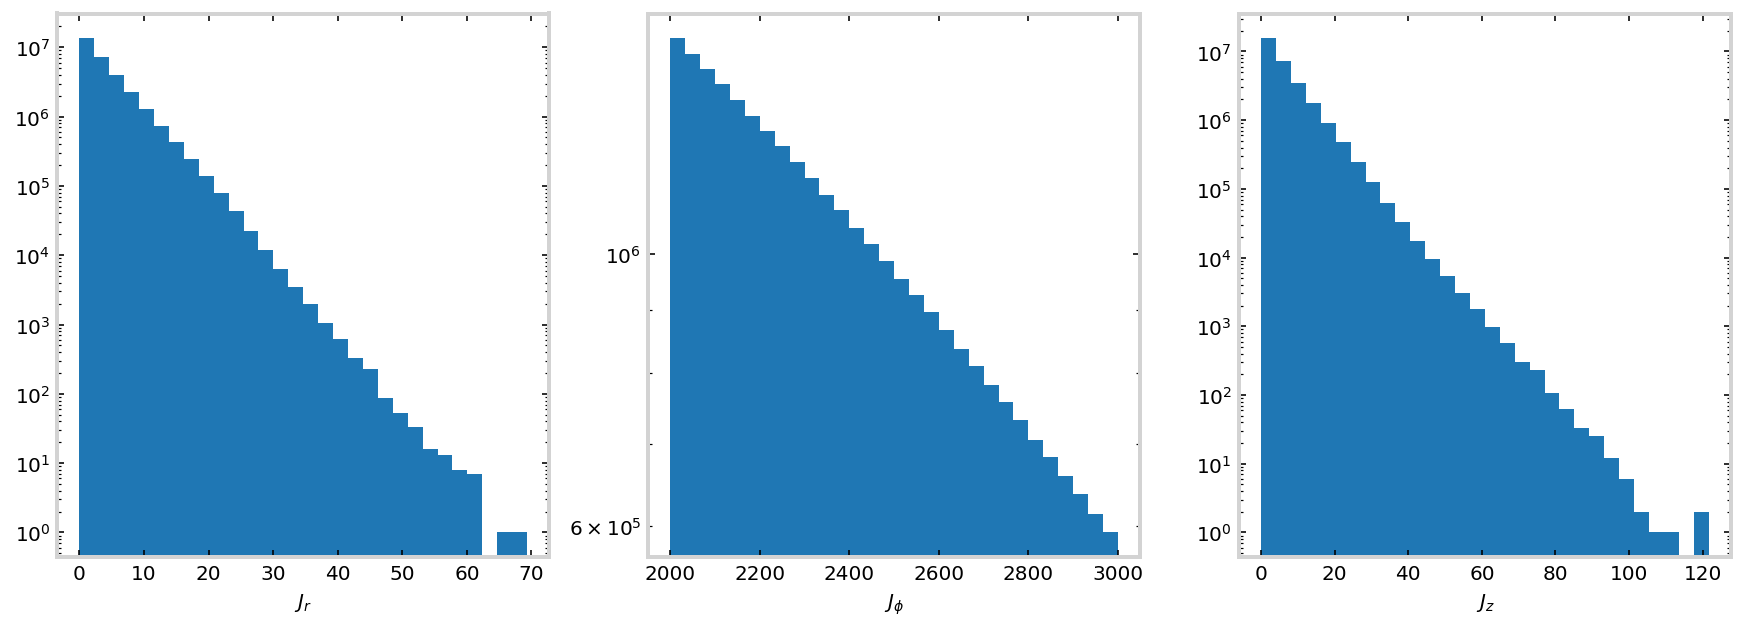

In [33]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer150.jr, bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer150.jphi, bins=30)
axs[1].set_xlabel(r'$J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer150.jz, bins=30)
axs[2].set_xlabel(r'$J_z$')
axs[2].set_yscale('log')
plt.show()

## Now Let's Plot $\Delta J$

In [49]:
outer_original450-outer100

,jr,jphi,jz,theta_r,theta_phi,theta_z,freq_r,freq_phi,freq_z
7307824,14.492394,-8.692126,0.321516,-0.352126,-4.210984,4.128808,-0.622852,-0.374184,-1.653961
7350889,4.980450,10.755767,-0.103098,0.066889,-3.809615,2.865103,-0.727299,-0.422200,-0.863289
7803125,4.566601,-18.742732,0.079770,1.115036,-3.406003,4.815163,-0.166262,-0.075393,-0.088268
7803863,14.215073,3.495749,-4.844158,2.054405,-2.800343,1.346871,-0.553373,-0.416016,0.370270
7803884,4.502549,-2.877410,1.857899,1.626567,-2.821404,-0.465655,-0.578371,-0.276131,-1.384589
...,...,...,...,...,...,...,...,...,...
217122776,4.728455,4.340005,-0.123797,2.349959,-2.381763,1.019656,-0.630311,-0.365891,0.890233
217165027,6.047844,18.338490,-0.175733,1.158854,-3.100785,1.045883,-0.882869,-0.542789,0.457298
217174529,10.618974,20.831137,-0.194350,5.277386,1.616542,1.484680,-0.946489,-0.638326,-1.199162
217174664,6.186910,2.550129,-0.395183,2.322415,-2.416415,-1.551527,-0.592726,-0.343026,0.157731


In [35]:
outer100

,jr,jphi,jz,theta_r,theta_phi,theta_z,freq_r,freq_phi,freq_z
7307824,40.234967,2028.700484,4.453812,0.951131,4.485245,0.702119,37.775812,25.947160,44.958237
7350889,47.575772,2008.444846,6.258643,0.462823,4.582793,0.118413,37.929980,25.979448,43.507139
7803125,23.520027,2005.024492,21.427098,0.583840,4.779485,0.573359,38.009333,26.066569,39.229121
7803863,13.835119,2000.387513,20.306840,0.913480,5.099350,1.967926,38.308020,26.313350,40.050842
7803884,22.168210,2003.147393,14.745752,1.823134,4.909807,3.108164,38.378629,26.244339,41.561053
...,...,...,...,...,...,...,...,...,...
217122776,33.111693,2009.503251,2.144872,0.929339,4.915529,2.160829,38.388401,26.346864,47.172744
217165027,32.785543,2022.879197,1.256727,0.757799,4.825554,1.541080,38.186351,26.230159,47.163640
217174529,40.809016,2035.646643,5.323548,0.382607,4.498681,1.598375,37.588498,25.839377,43.562866
217174664,32.565635,2001.353716,7.179095,0.962769,4.894033,3.800210,38.336470,26.314789,44.512237


In [37]:
outer450

,jr,jphi,jz,theta_r,theta_phi,theta_z,freq_r,freq_phi,freq_z
7307824,54.727361,2020.008358,4.775329,0.599005,0.274261,4.830927,37.152961,25.572976,43.304276
7325523,35.487428,2003.253471,7.831816,3.196759,2.637577,3.662517,37.809370,25.988687,44.038641
7350889,52.556222,2019.200613,6.155545,0.529712,0.773178,2.983516,37.202681,25.557248,42.643850
7803512,30.257229,2001.536185,34.695435,1.137124,0.701744,5.927034,37.255322,25.450367,35.821446
7803863,28.050192,2003.883262,15.462682,2.967885,2.299007,3.314796,37.754647,25.897335,40.421112
...,...,...,...,...,...,...,...,...,...
217174529,51.427990,2056.477780,5.129198,5.659993,6.115223,3.083055,36.642009,25.201051,42.363704
217174664,38.752545,2003.903845,6.783912,3.285185,2.477618,2.248682,37.743744,25.971763,44.669968
217176441,30.624958,2000.397294,2.511144,4.876207,3.559862,1.059807,38.148338,26.258507,47.196194
217190698,45.185889,2019.674172,11.223521,0.565693,0.744255,4.274178,37.133757,25.573222,40.896382


These are histograms where I am subtracting the outer disk populations from one another at different times, but on a star-by-star basis, meaning that I am only seeing $\Delta J$ for stars that are in the outer disk $(2000 < J_{\phi} < 3000)$ in both timesteps

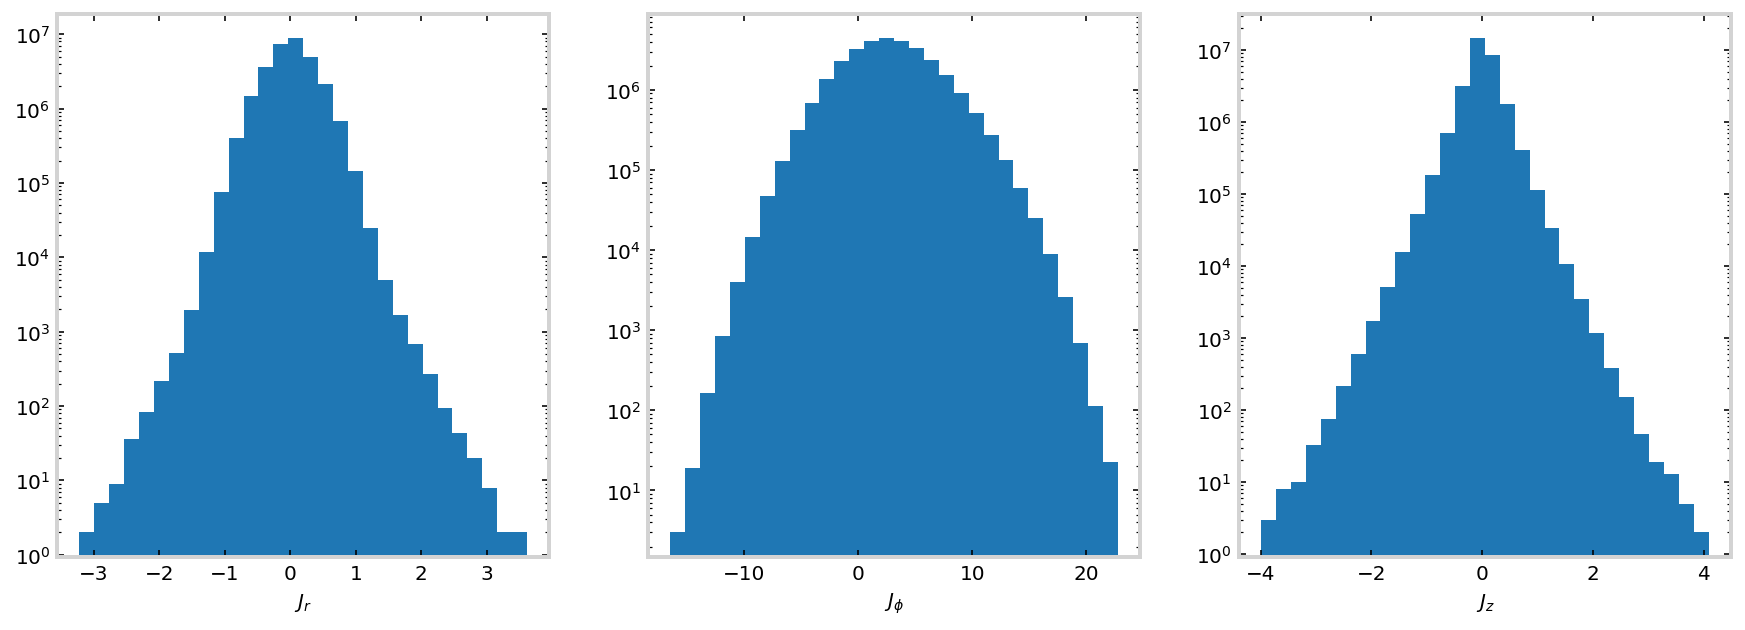

In [39]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer150.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer150.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer150.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

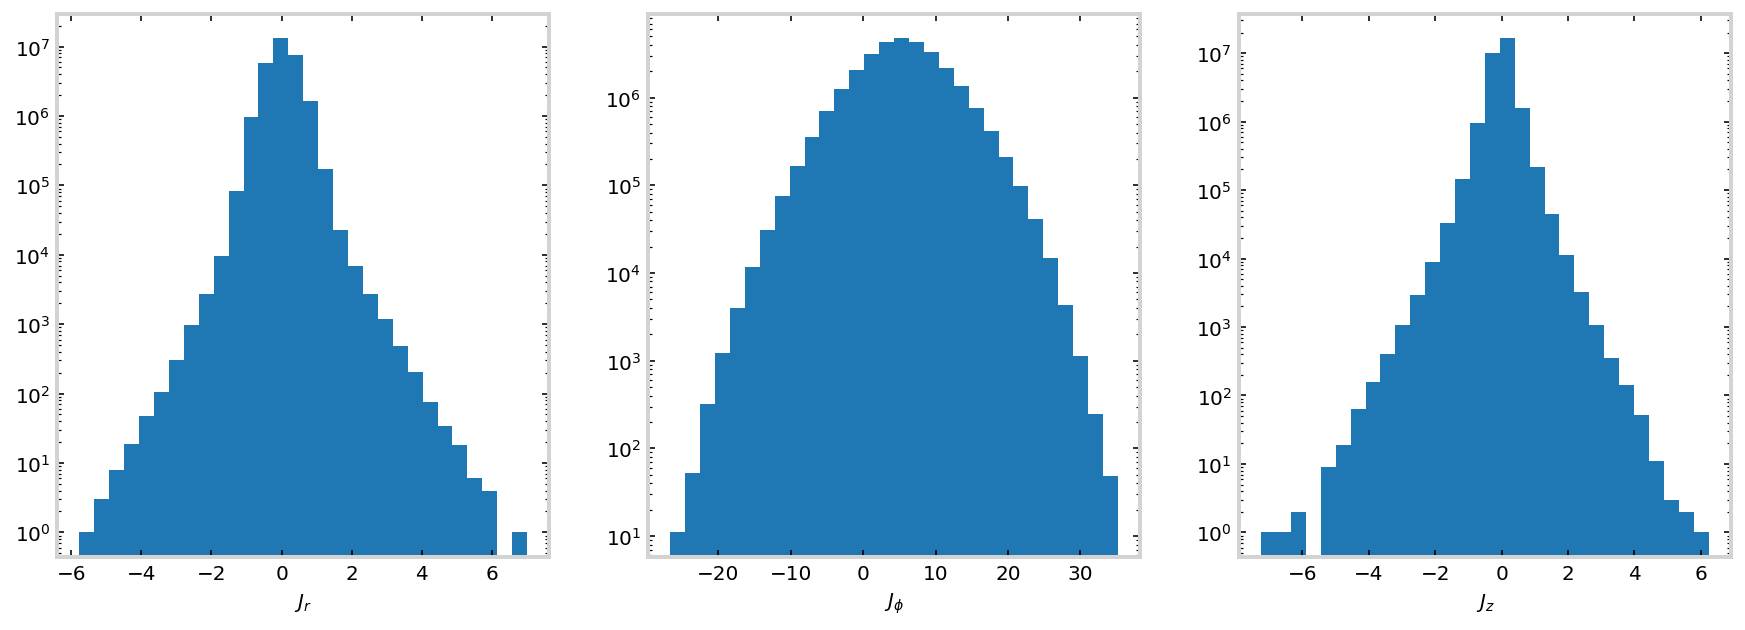

In [40]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer200.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer200.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer200.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

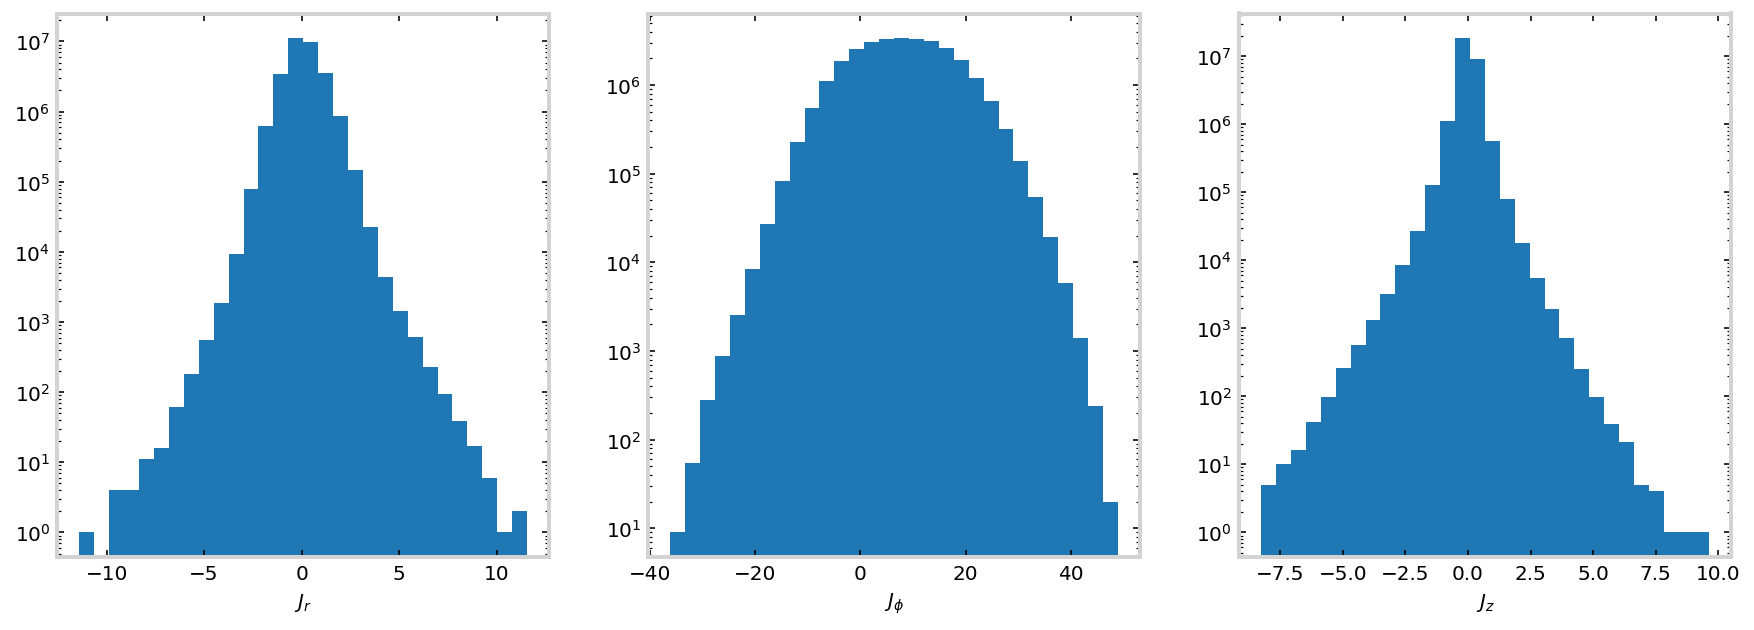

In [41]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer250.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer250.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer250.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

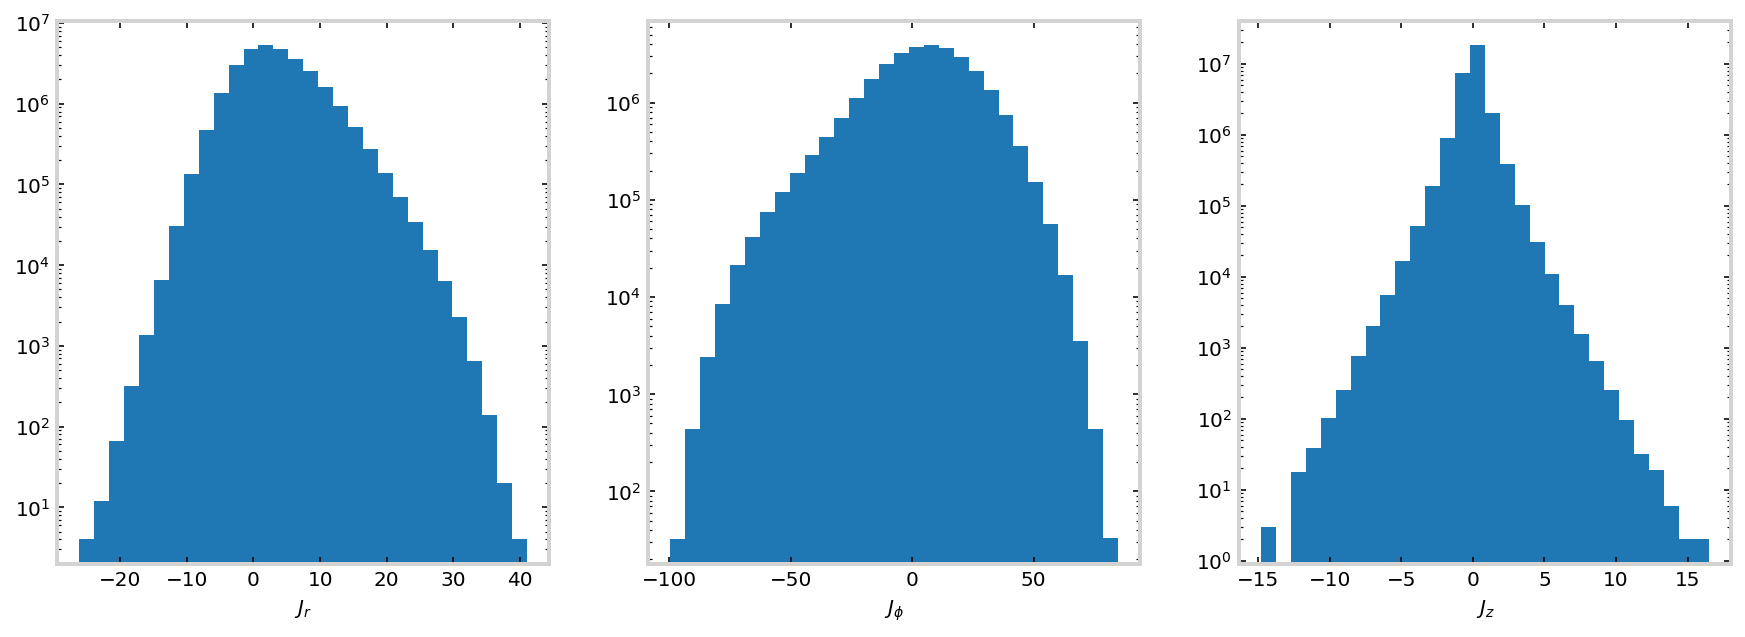

In [42]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer300.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer300.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer300.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

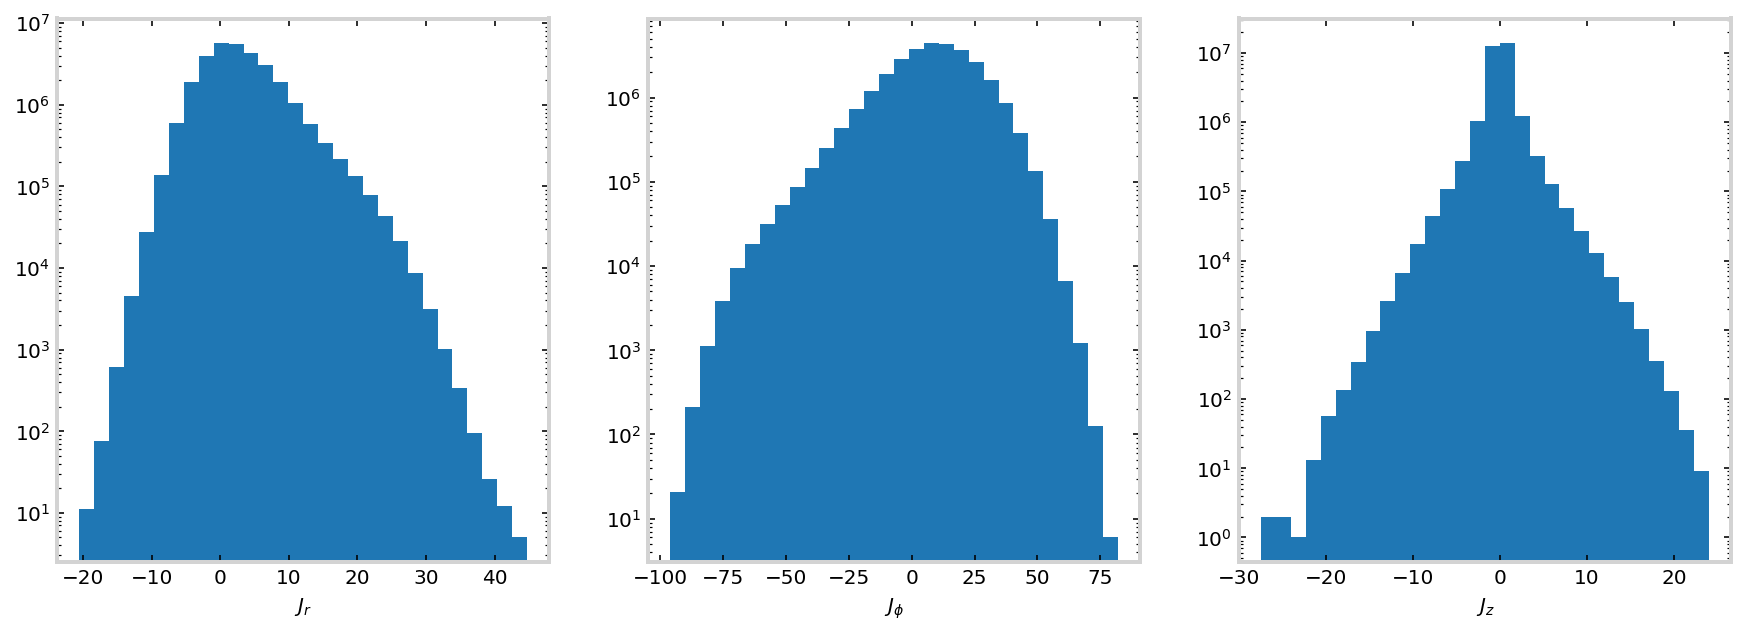

In [43]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer350.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer350.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer350.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

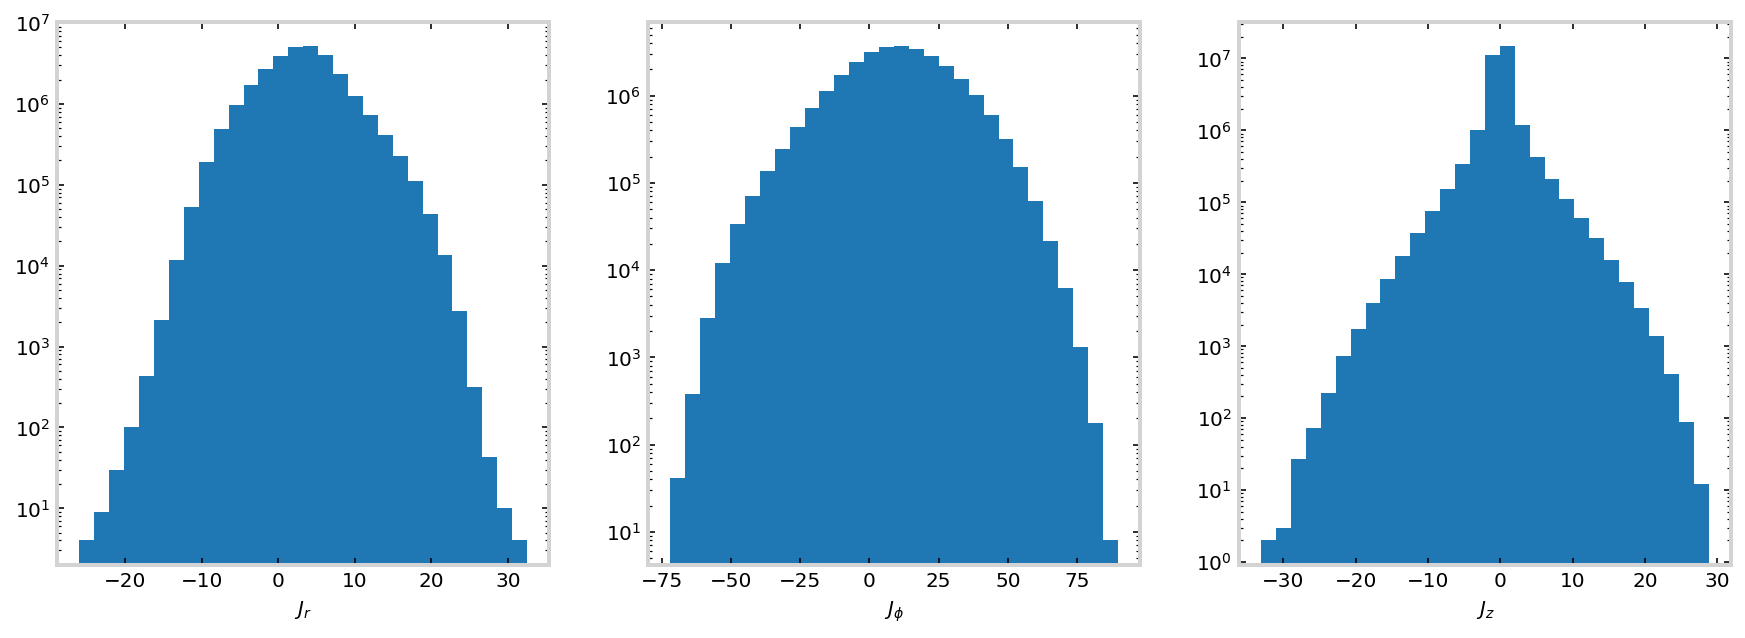

In [ ]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer400.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer400.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer400.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

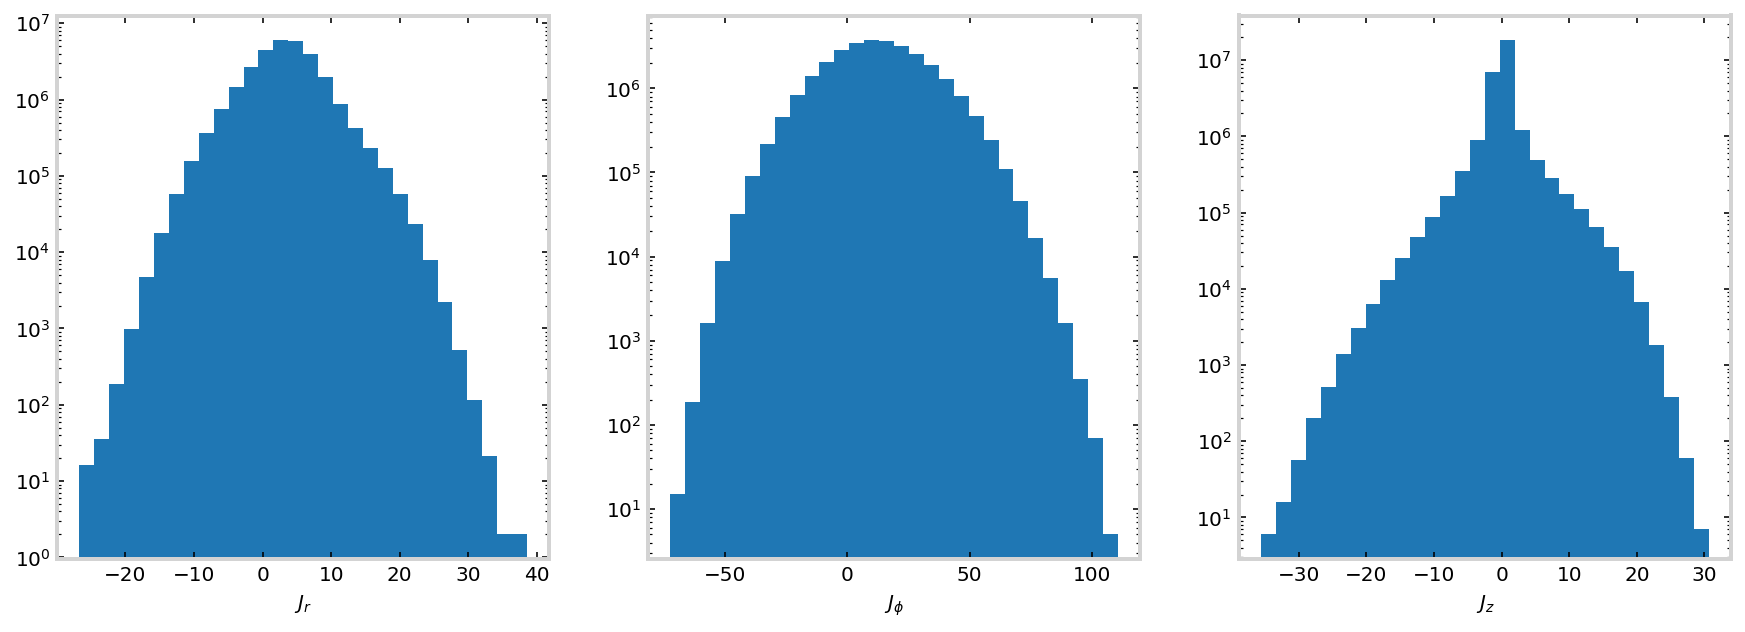

In [45]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer450.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer450.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer450.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

The other histograms I can make are $\Delta J$ for any stars that were originally in the outer disk, no matter where they are now:

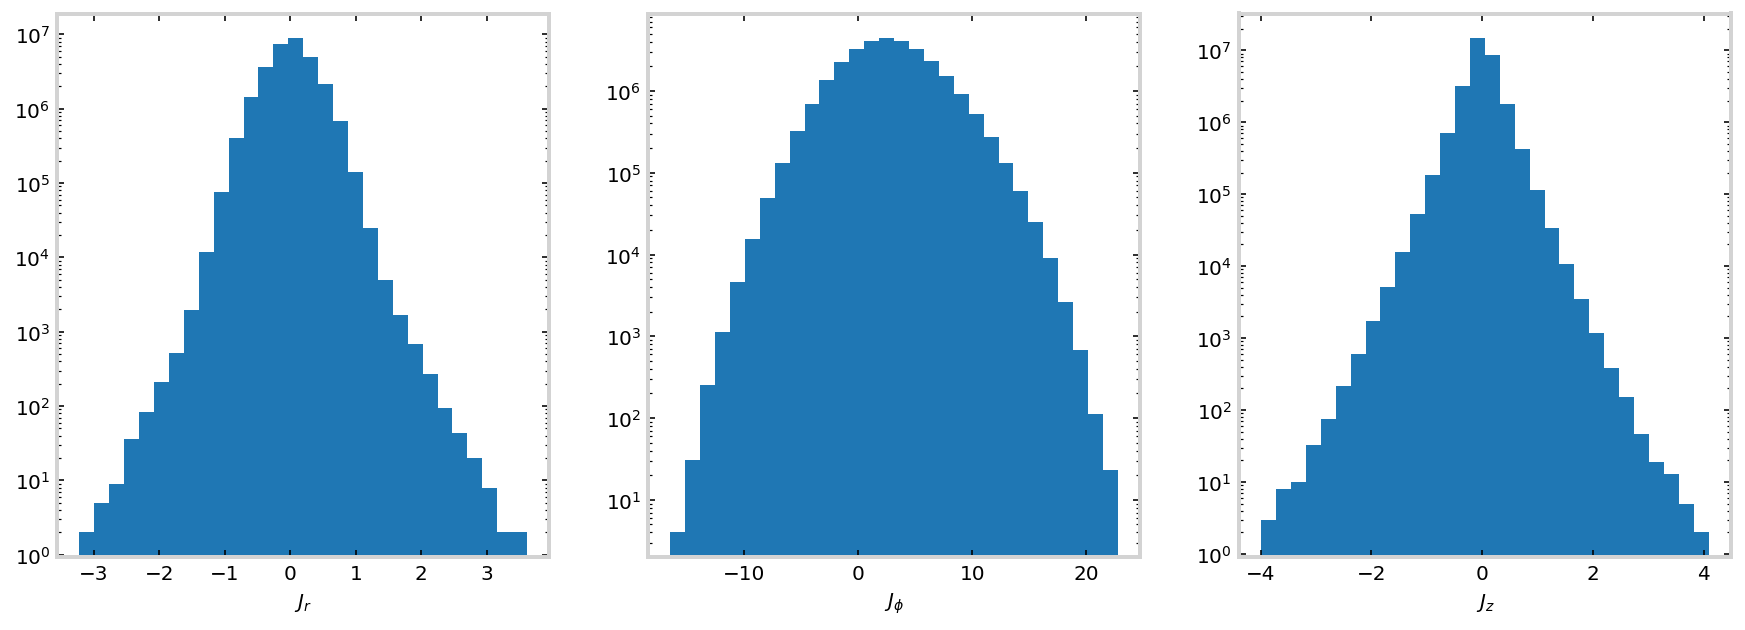

In [48]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original150.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original150.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original150.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

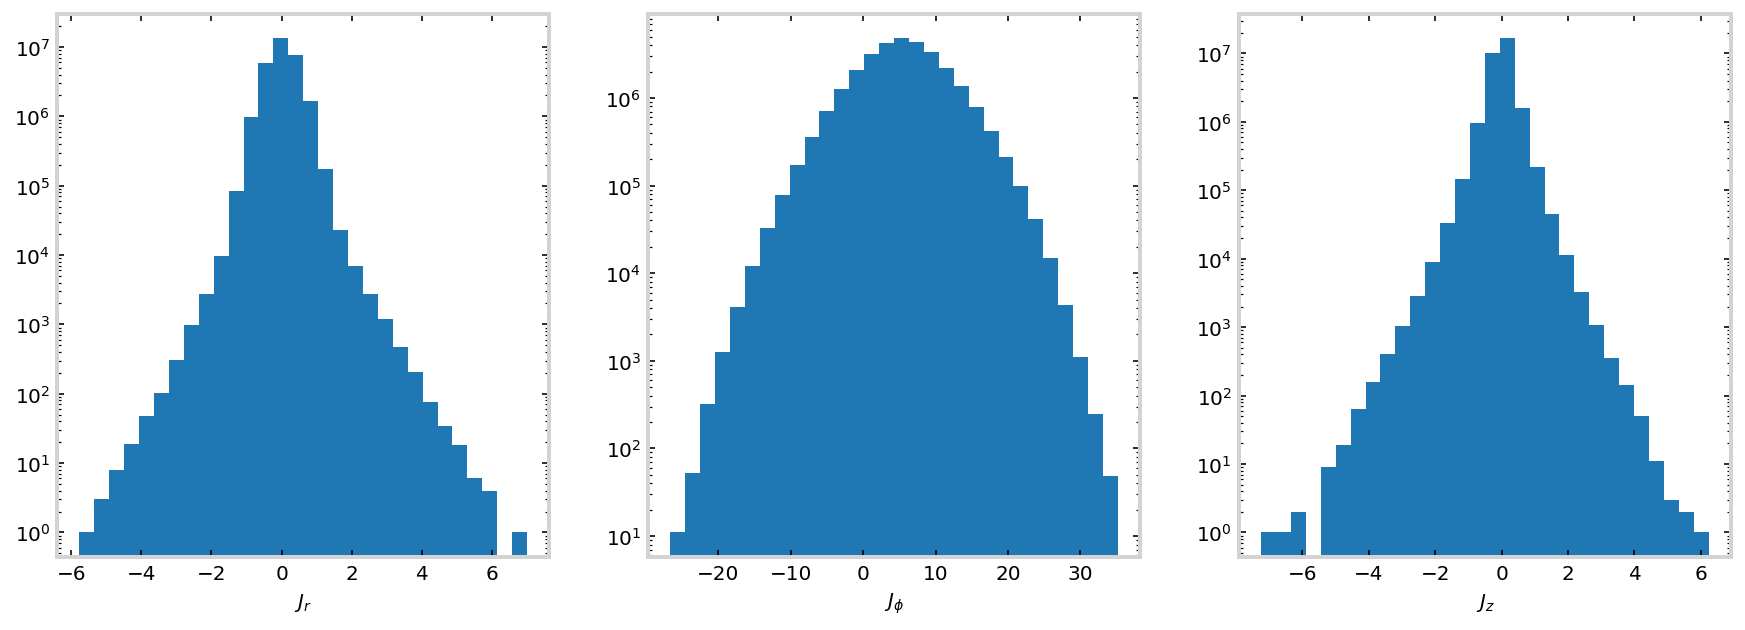

In [50]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original200.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original200.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original200.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

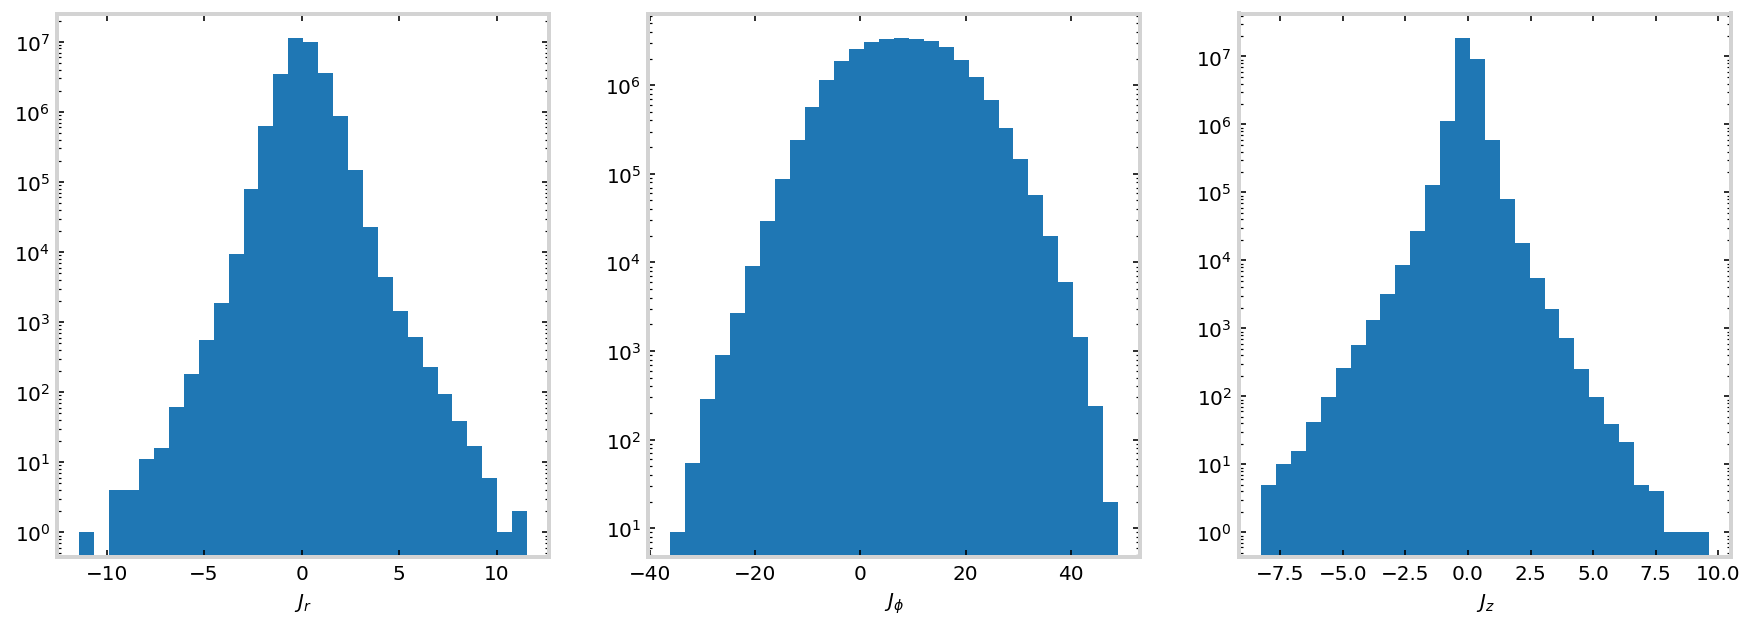

In [51]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original250.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original250.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original250.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

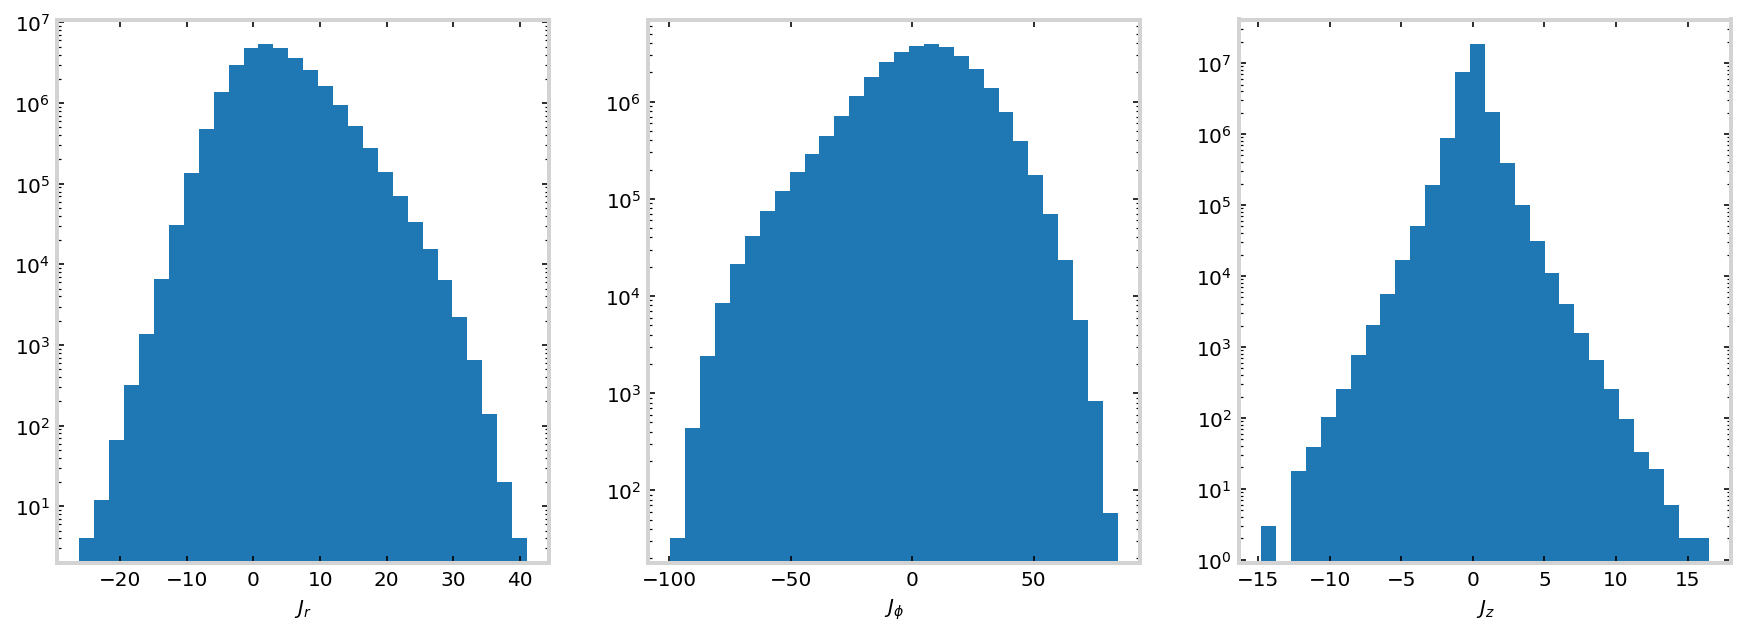

In [52]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original300.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original300.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original300.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

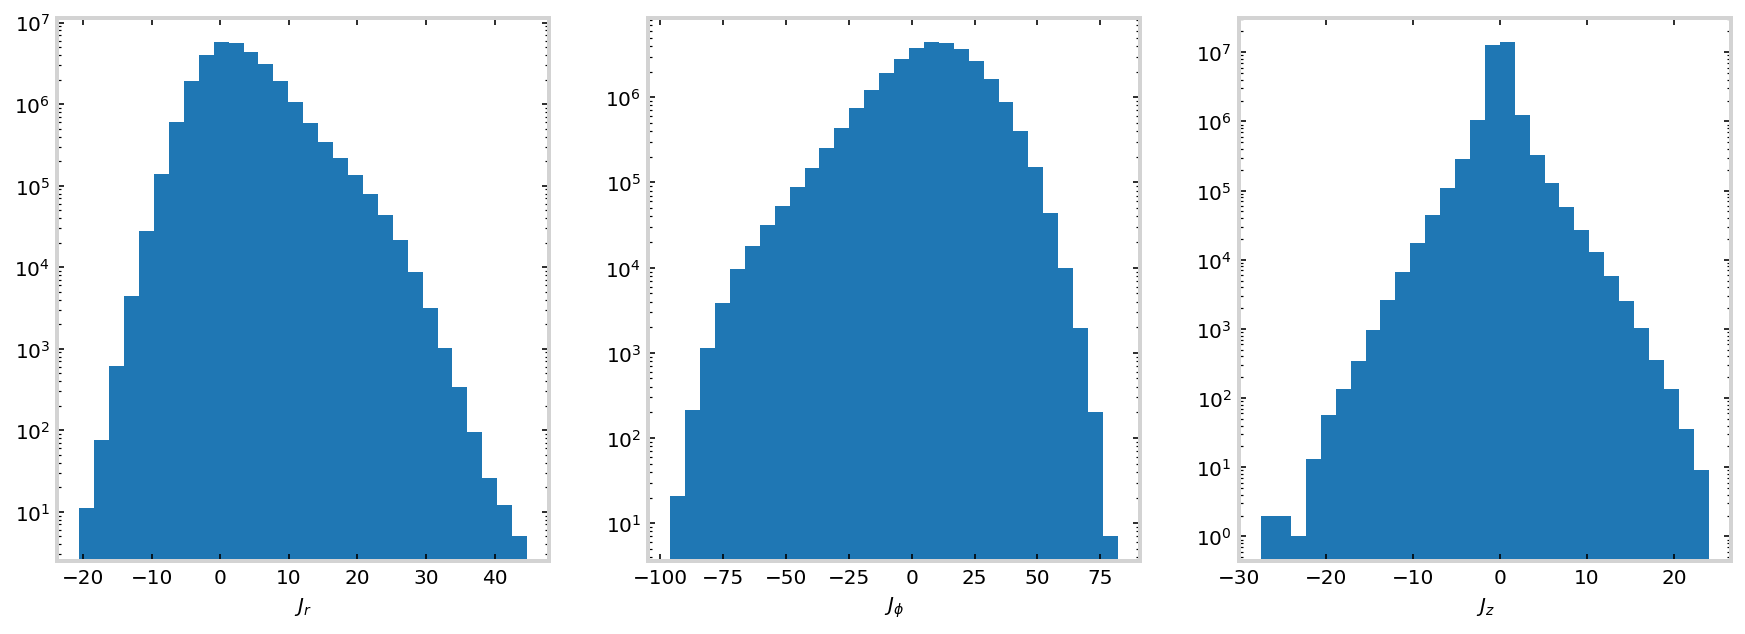

In [53]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original350.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original350.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original350.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

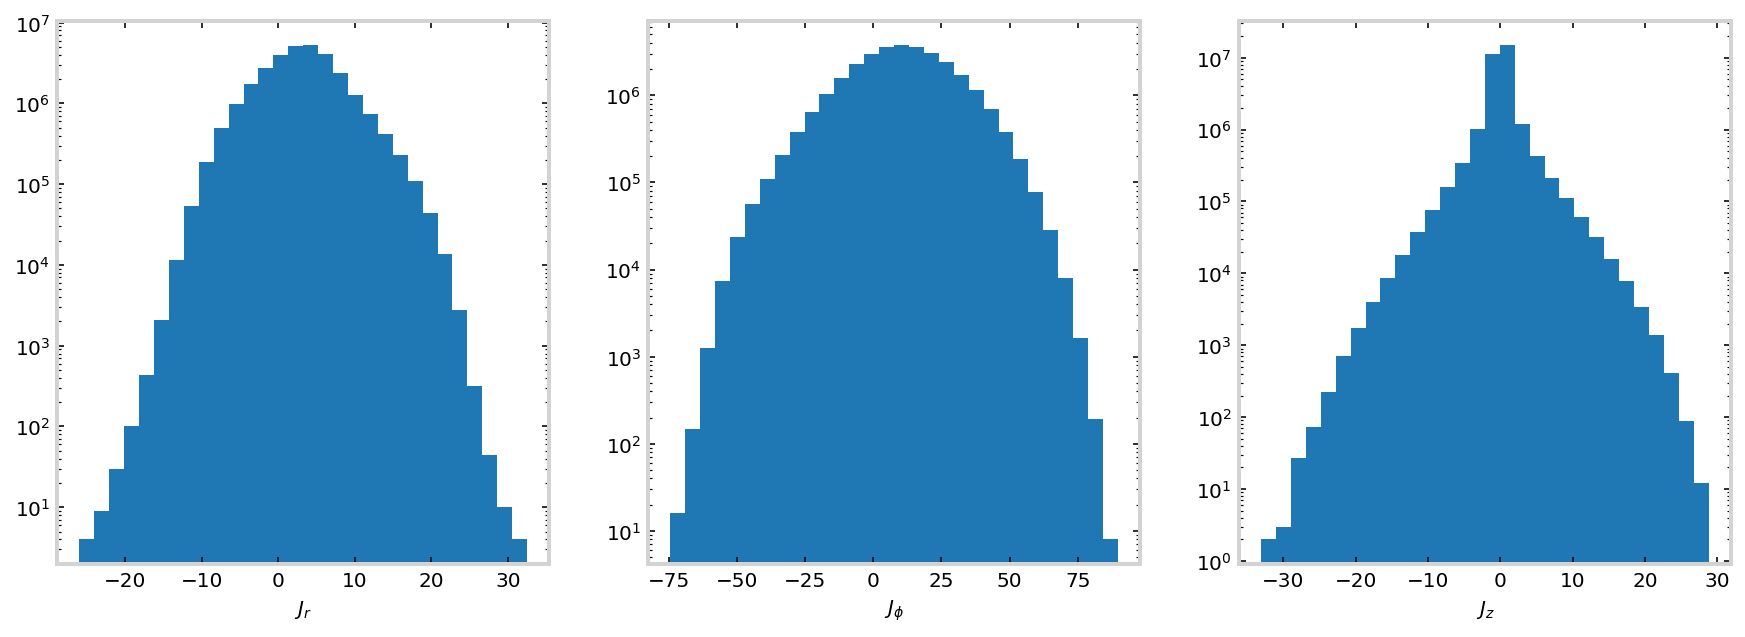

In [54]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original400.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original400.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original400.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

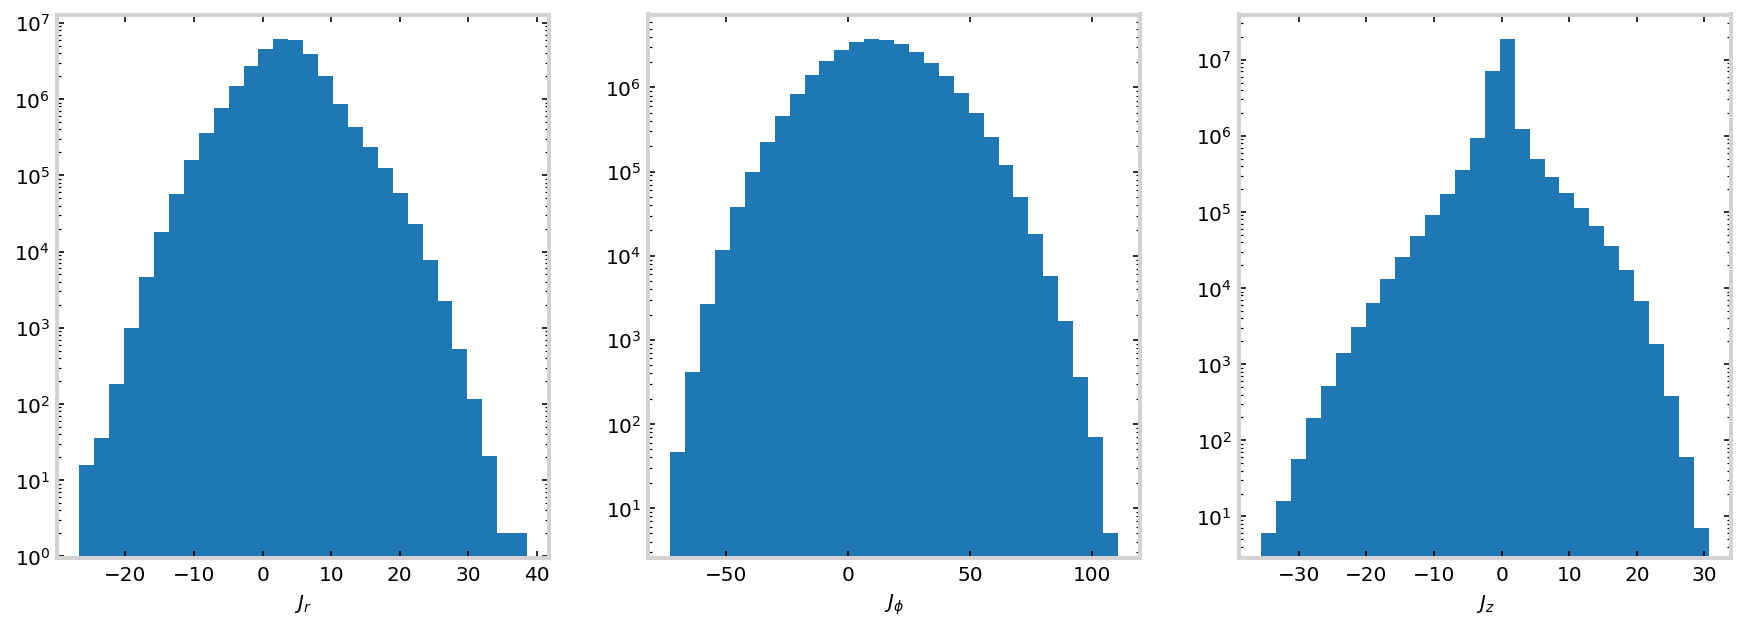

In [55]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original450.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original450.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original450.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

## Let's Make 2D Histograms

Text(0.5, 0, '$\\Delta J_z$')

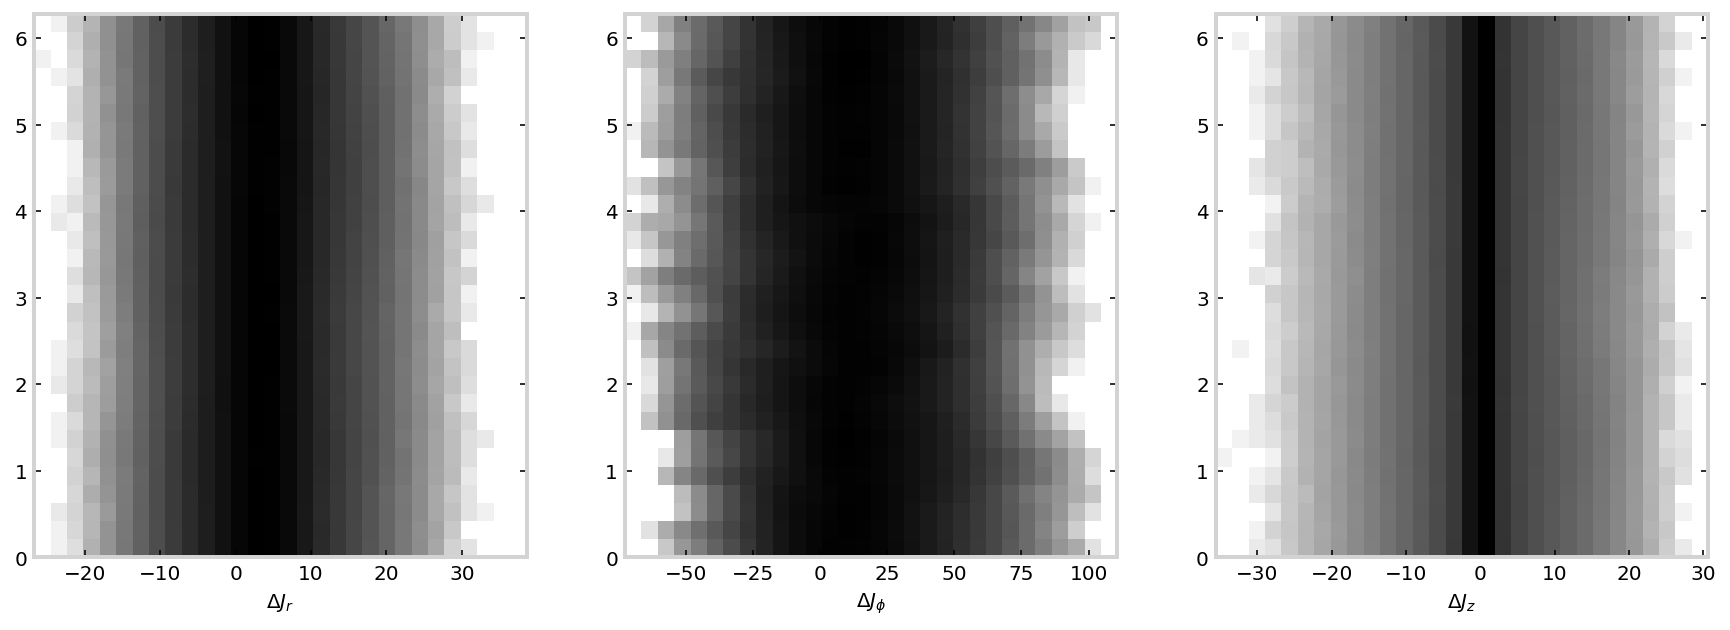

In [61]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer_original450.jr - outer100.jr, outer100.theta_phi, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].hist2d(outer_original450.jphi - outer100.jphi, outer100.theta_phi, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[1].set_xlabel(r'$\Delta J_\phi$')

axs[2].hist2d(outer_original450.jz - outer100.jz, outer100.theta_phi, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[2].set_xlabel(r'$\Delta J_z$')

I want to make eye plots colored by $\Delta J$

In [60]:
thetas = np.arange(0, 2*np.pi, 32)
delta_jrs = np.arange(-30,30,50)
delta_jphis = np.arange(-100,100,50)
delta_jzs = np.arange(-30,30,50)

T, R = np.meshgrid(thetas, delta_jrs)
T, PHI = np.meshgrid(thetas, delta_jphis)
T, Z = np.meshgrid(thetas, delta_jzs)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].pcolormesh(T, R, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].pcolormesh(T, PHI, ,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[1].set_xlabel(r'$\Delta J_\phi$')

axs[2].pcolormesh(T, Z, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[2].set_xlabel(r'$\Delta J_z$')

## Looking at Populations in Annuli At Different Times

Split up the outer disk into smaller annuli. Also focus on $J_r$ from now on.

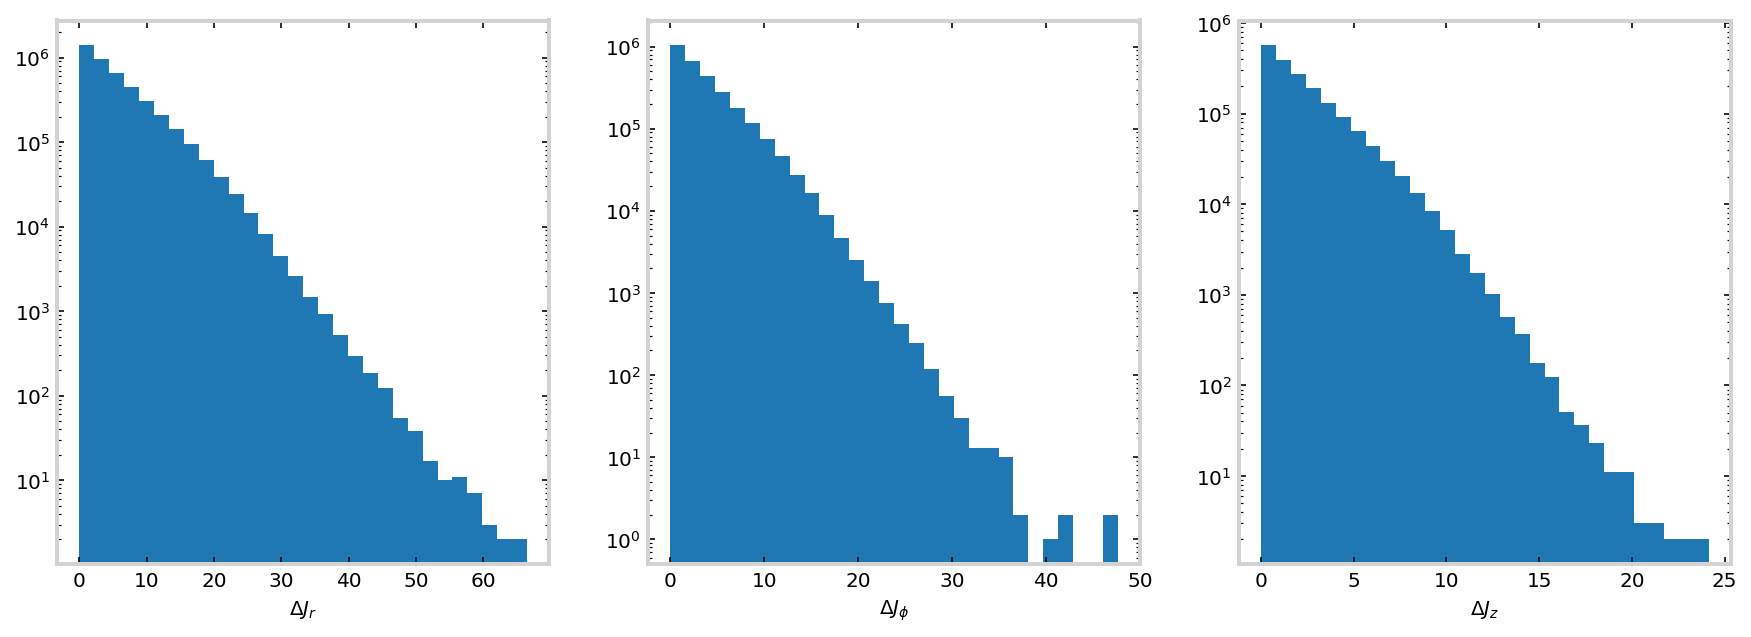

In [62]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer100.jr[(outer100.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer100.jr[(outer100.jphi > 2450) & (outer100.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer100.jr[(outer100.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

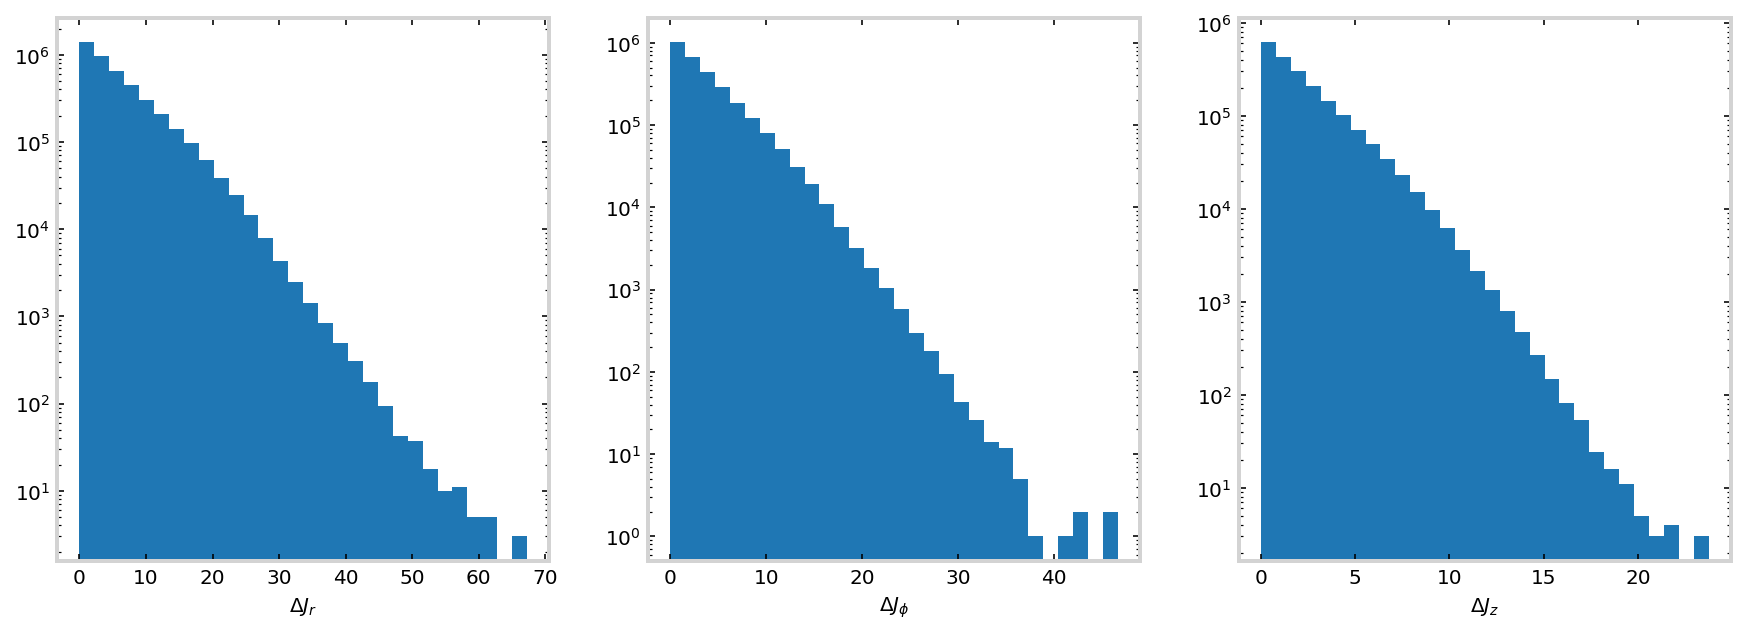

In [63]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer200.jr[(outer200.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer200.jr[(outer200.jphi > 2450) & (outer200.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer200.jr[(outer200.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

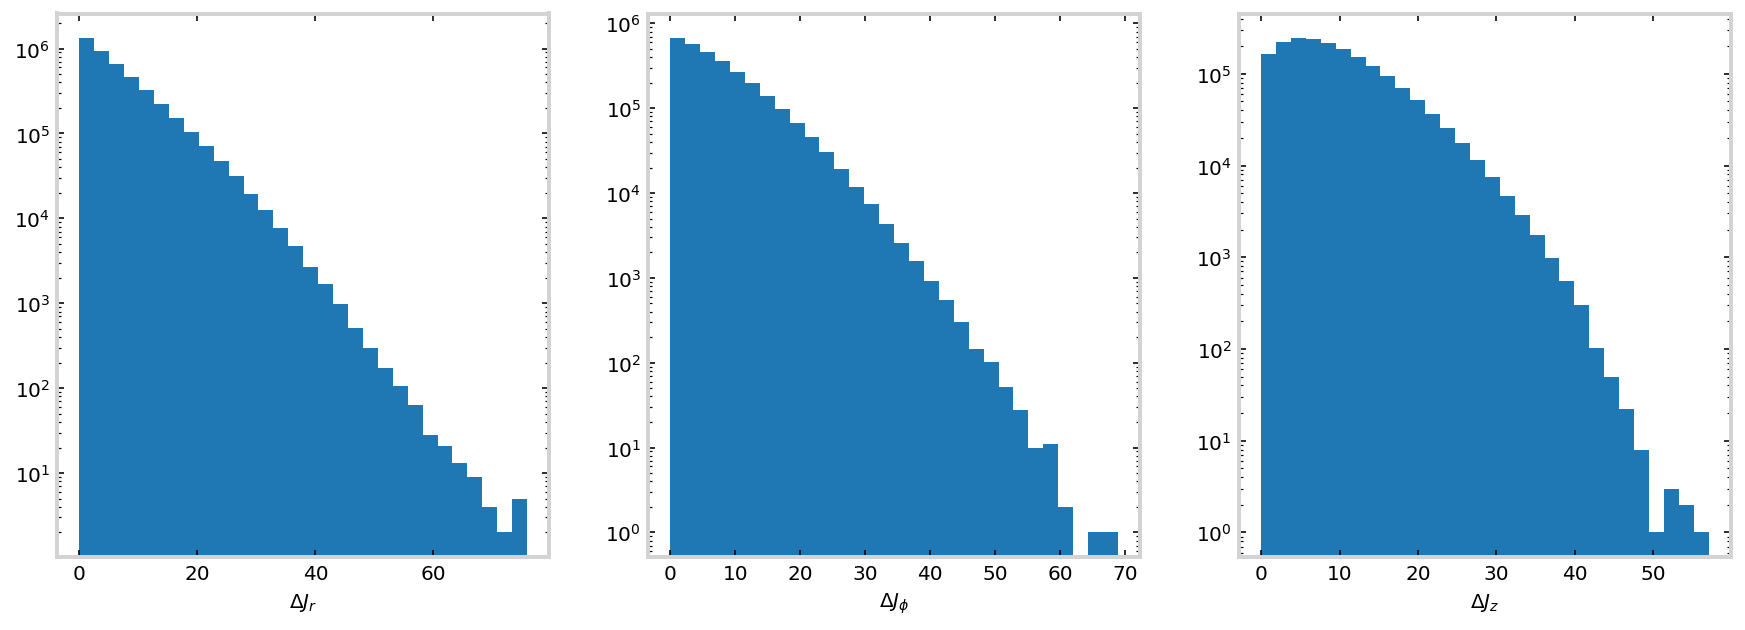

In [64]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer300.jr[(outer300.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer300.jr[(outer300.jphi > 2450) & (outer300.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer300.jr[(outer300.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.show()

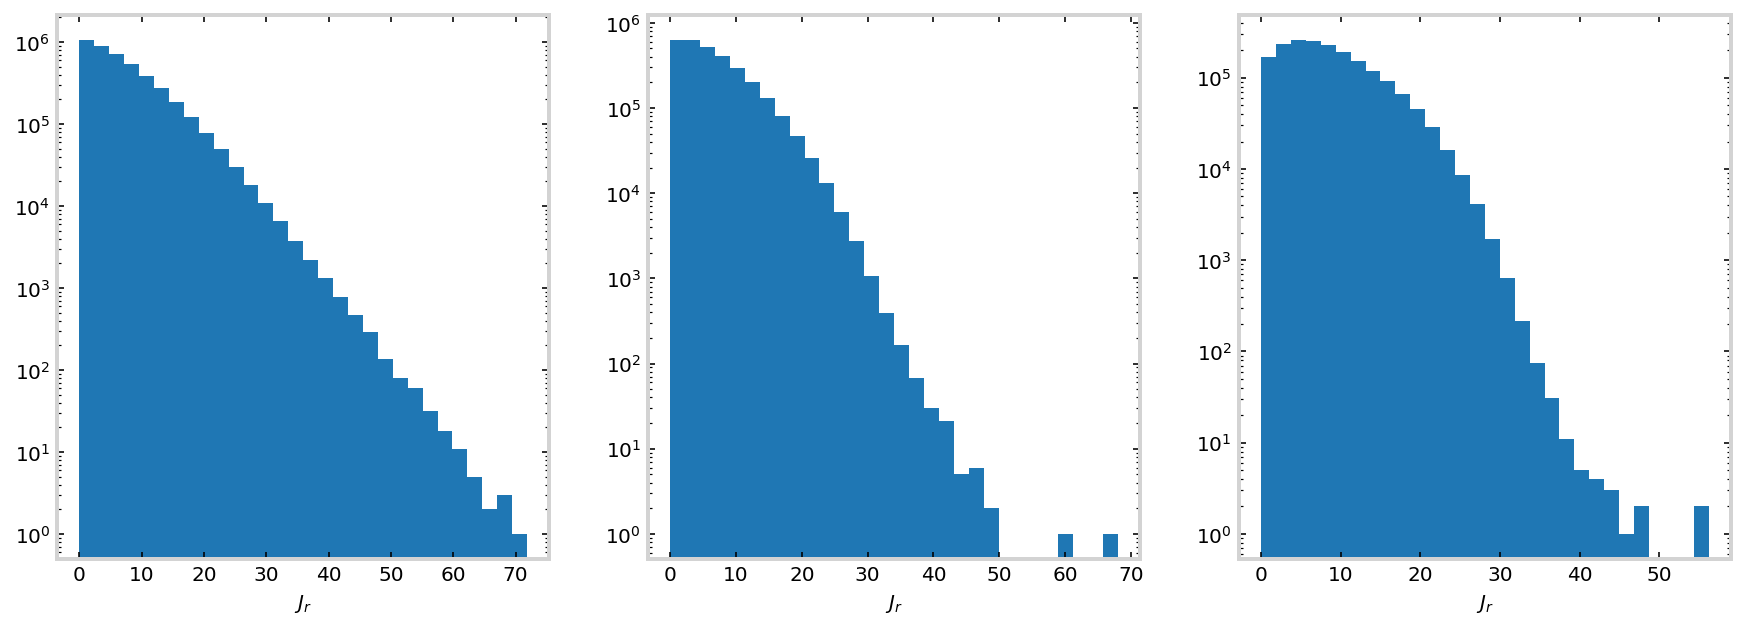

In [72]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer400.jr[(outer400.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer400.jr[(outer400.jphi > 2450) & (outer400.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')
axs[1].set_yscale('log')

axs[2].hist(outer400.jr[(outer400.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
axs[2].set_yscale('log')
plt.show()

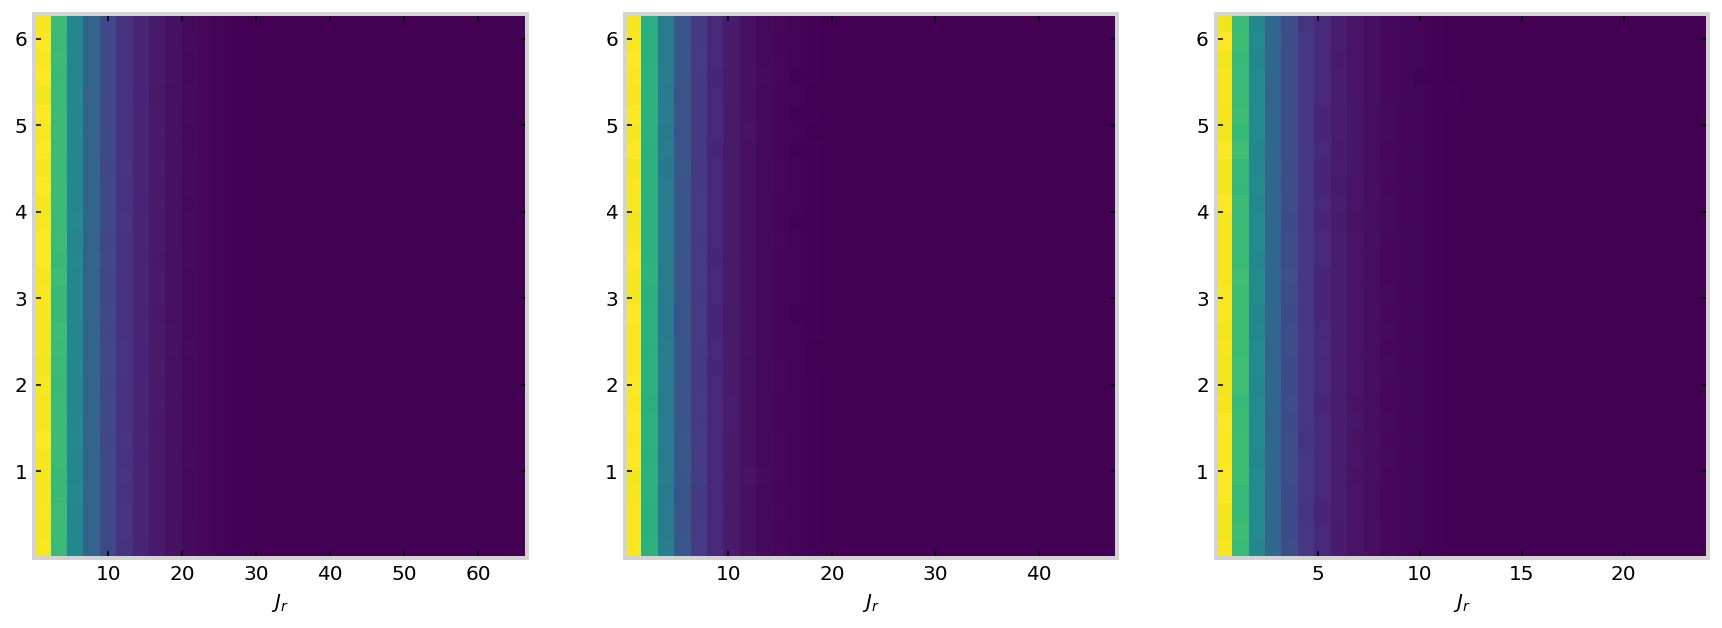

In [74]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer100.jr[(outer100.jphi < 2100)], outer100.theta_phi[(outer100.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer100.jr[(outer100.jphi > 2450) & (outer100.jphi < 2550)], 
              outer100.theta_phi[(outer100.jphi > 2450) & (outer100.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer100.jr[(outer100.jphi > 2900)], outer100.theta_phi[(outer100.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.show()

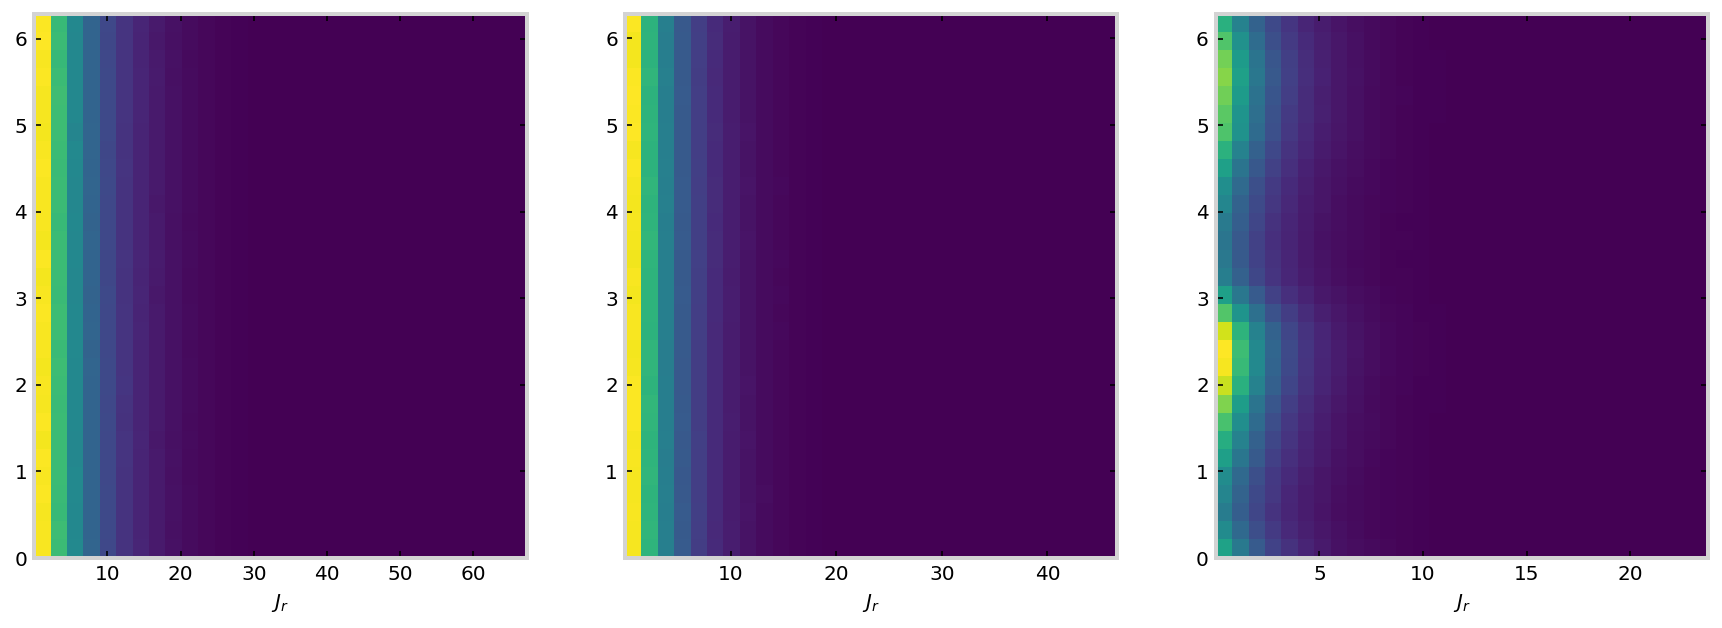

In [82]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer200.jr[(outer200.jphi < 2100)], outer200.theta_phi[(outer200.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer200.jr[(outer200.jphi > 2450) & (outer200.jphi < 2550)], 
              outer200.theta_phi[(outer200.jphi > 2450) & (outer200.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer200.jr[(outer200.jphi > 2900)], outer200.theta_phi[(outer200.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.show()

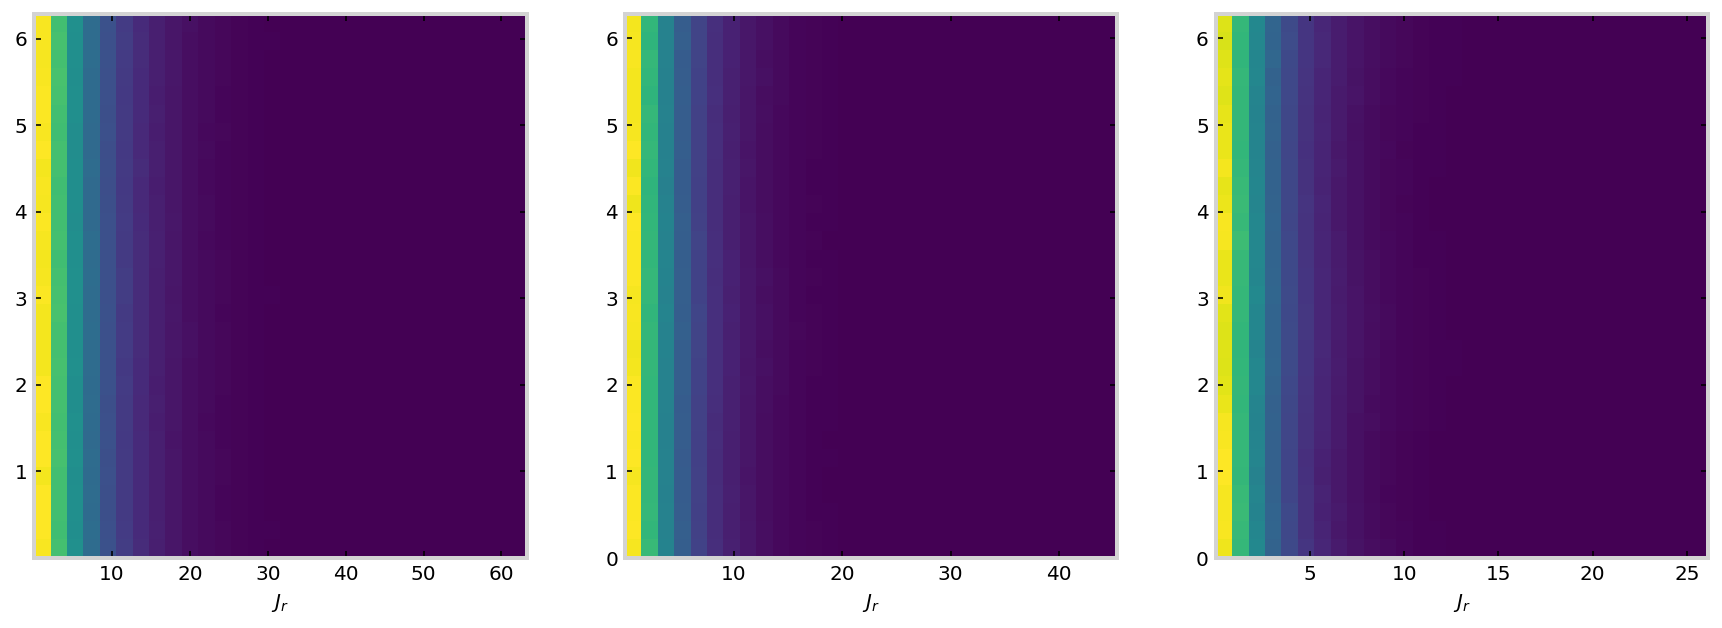

In [83]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer250.jr[(outer250.jphi < 2100)], outer250.theta_phi[(outer250.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer250.jr[(outer250.jphi > 2450) & (outer250.jphi < 2550)], 
              outer250.theta_phi[(outer250.jphi > 2450) & (outer250.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer250.jr[(outer250.jphi > 2900)], outer250.theta_phi[(outer250.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.show()

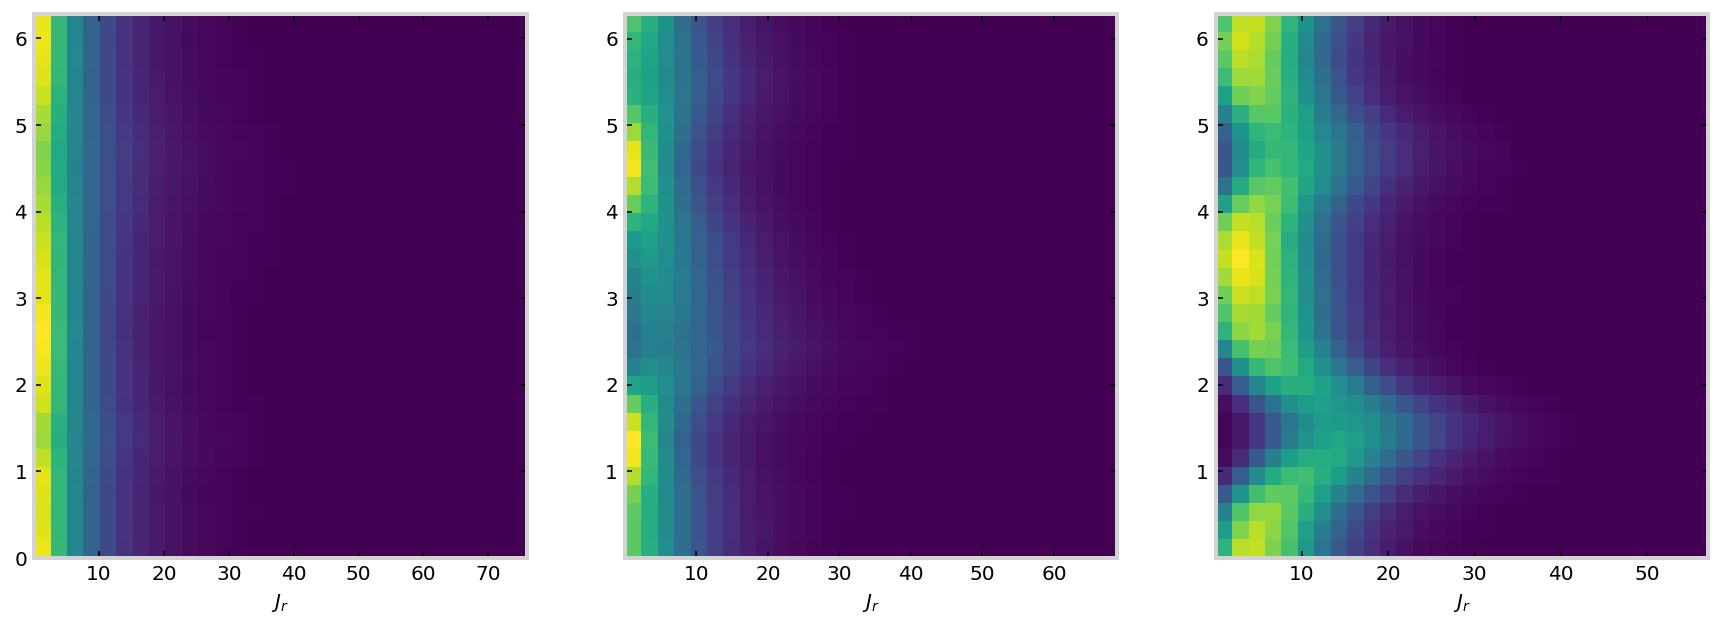

In [84]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer300.jr[(outer300.jphi < 2100)], outer300.theta_phi[(outer300.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer300.jr[(outer300.jphi > 2450) & (outer300.jphi < 2550)], 
              outer300.theta_phi[(outer300.jphi > 2450) & (outer300.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer300.jr[(outer300.jphi > 2900)], outer300.theta_phi[(outer300.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.show()

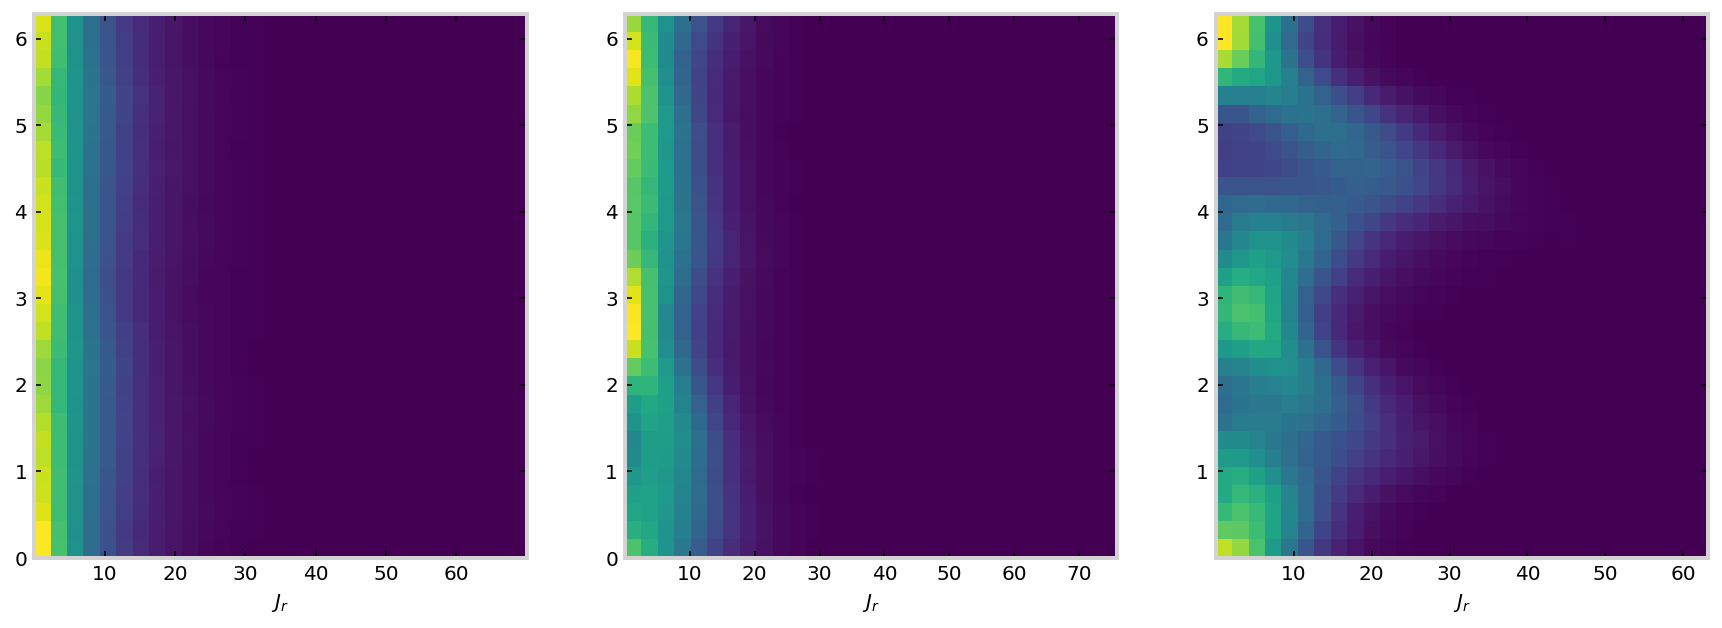

In [76]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer350.jr[(outer350.jphi < 2100)], outer350.theta_phi[(outer350.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer350.jr[(outer350.jphi > 2450) & (outer350.jphi < 2550)], 
              outer350.theta_phi[(outer350.jphi > 2450) & (outer350.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer350.jr[(outer350.jphi > 2900)], outer350.theta_phi[(outer350.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.show()

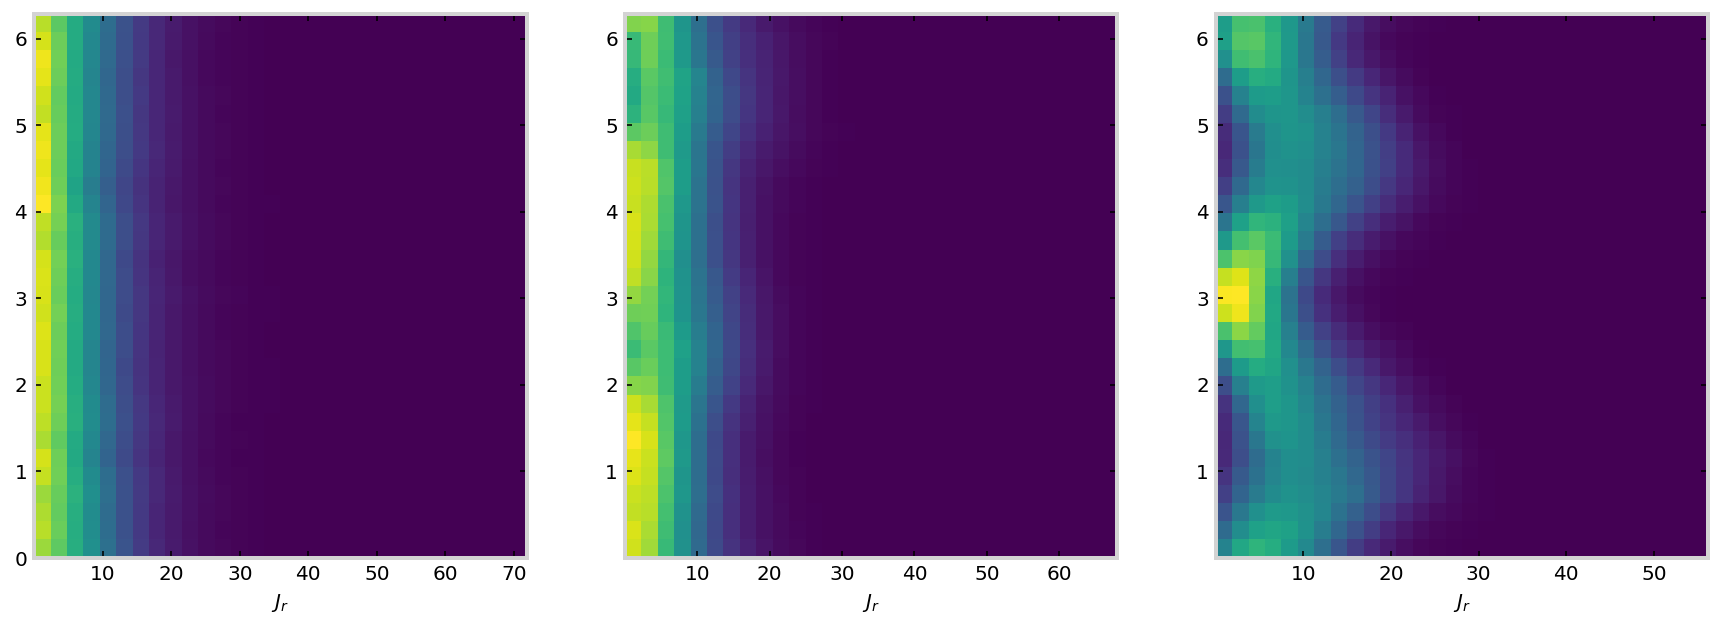

In [77]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer400.jr[(outer400.jphi < 2100)], outer400.theta_phi[(outer400.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer400.jr[(outer400.jphi > 2450) & (outer400.jphi < 2550)], 
              outer400.theta_phi[(outer400.jphi > 2450) & (outer400.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer400.jr[(outer400.jphi > 2900)], outer400.theta_phi[(outer400.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.show()

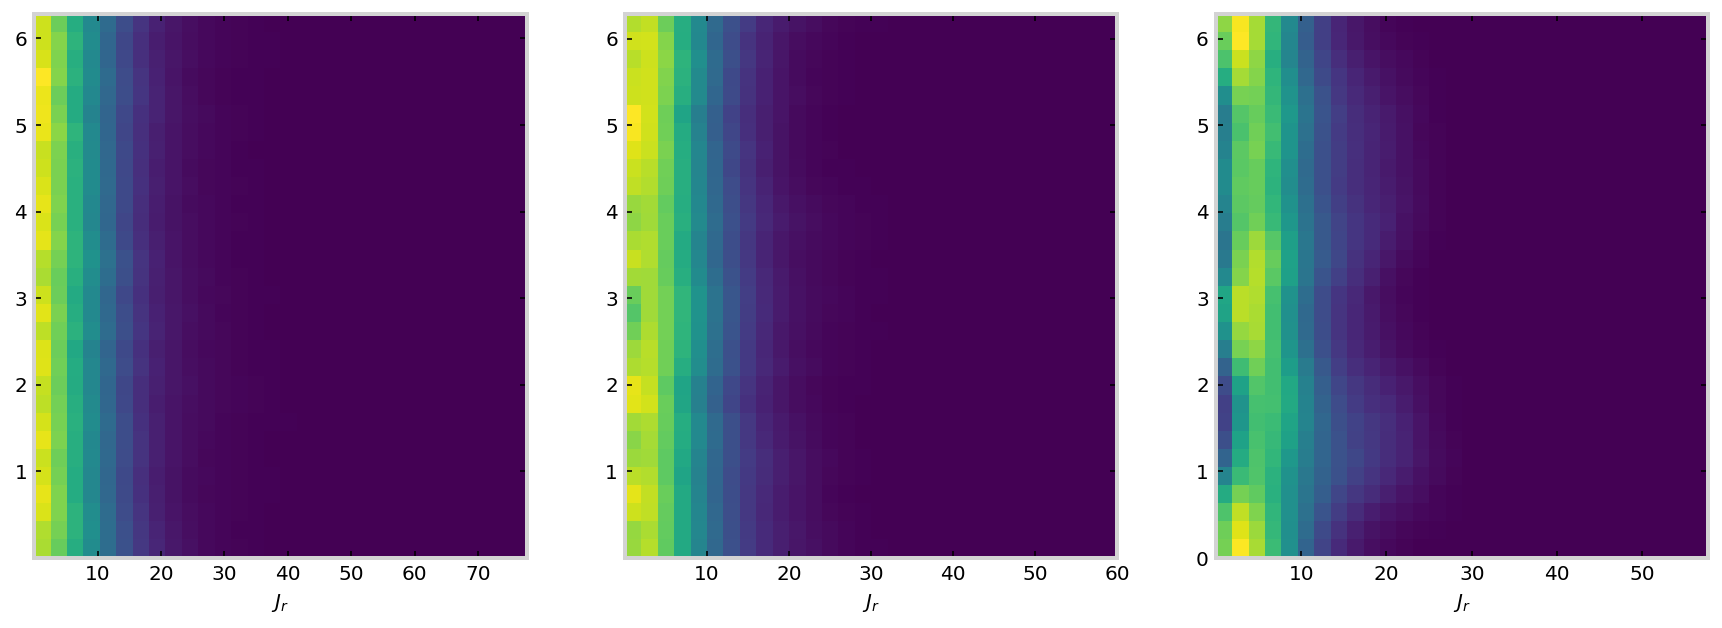

In [79]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer450.jr[(outer450.jphi < 2100)], outer450.theta_phi[(outer450.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer450.jr[(outer450.jphi > 2450) & (outer450.jphi < 2550)], 
              outer450.theta_phi[(outer450.jphi > 2450) & (outer450.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer450.jr[(outer450.jphi > 2900)], outer450.theta_phi[(outer450.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.show()